In [183]:
import numpy as np 
import matplotlib.pyplot as plt 


# 1-D Hydrodynamics #

@autor:     Dario Hug

@date:      09.12.2024

With these methods
- LAX
- Lax-Friedrichs Riemann solver
- Lax-Friedrichs Riemann solver with predictor-corrector steps

solve these two problems
- Shock tube
- Sedov-Taylor blast wave

$ F = \begin{bmatrix} \rho u \\ \rho u^2 + p \\ u(\frac{1}{2} \rho u^2 + \frac{3}{2}p) \end{bmatrix} $ 

In [184]:
def calculateFlux(U, gamma):
    
    rho = U[:, 0]       # dens
    assert all(rho) > 0, f"rho is negativ {rho}"
    u = U[:, 1] / rho   # momentum
    E = U[:, 2]         # energy density
        
    preassure = (gamma - 1) * (E - 0.5 * rho * u**2)

    F = np.column_stack((rho * u, 
                         rho * u ** 2 + preassure, 
                         u * (E + preassure)))

    return F

$ F = \begin{bmatrix} \rho u \\ \rho u^2 + p \\ u(\frac{1}{2} \rho u^2 + \frac{3}{2}p) \end{bmatrix} $ 

$ D_{max} = |u| + C_s $

$ C_s = \sqrt{\gamma \frac{p}{\rho}} $ 

In [185]:
def calcdmax(UL, UR, gamma):
    # Extract state variables for left and right states
    rho_l = UL[:, 0]        # dens
    u_l = UL[:, 1] / rho_l  # momentum
    E_l = UL[:, 2]          # energy density

    preassure_l = (gamma - 1) * (E_l - (1/2) * rho_l * u_l**2)
    cs_l = np.sqrt(gamma * preassure_l / rho_l)

    rho_r = UR[:, 0]        # dens
    u_r = UR[:, 1] / rho_r  # momentum
    E_r = UR[:, 2]          # energy density

    preassure_r = (gamma - 1) * (E_r - (1/2) * rho_r * u_r**2)
    
    cs_r= np.sqrt(gamma * preassure_r / rho_r)

    return np.maximum(np.abs(u_l) + cs_l, np.abs(u_r) + cs_r)

$ F_{i-\frac{1}{2}}^n = \frac{1}{2} (F_i^n + F_{i-1}^n) - \frac{1}{2} D_{max} (u_i^n - u_{i-1}^n) $


In [186]:
def RiemannSolver(UL, UR, gamma):

    D_max = calcdmax(UL, UR, gamma)

    F_l = calculateFlux(UL, gamma)
    F_r = calculateFlux(UR, gamma)

    return 0.5 * (F_r + F_l) - 0.5 * D_max[:, None] * (UR - UL)



$ u_i^{n+1} = \frac{1}{2} (U_{i+1}^n + U_{i-1}^n) - \frac{\Delta t}{2 \Delta x} (F_{i+1}^{n} - F_{i-1}^{n}) $ 

$ F = \begin{bmatrix} \rho u \\ \rho u^2 + p \\ u(\frac{1}{2} \rho u^2 + \frac{3}{2}p) \end{bmatrix} $ 


In [187]:
def methodA(U, deltaT, deltaX, gamma):
    F = calculateFlux(U, gamma)

    U_plus = np.roll(U, -1, 0)   # Shift the array `U` to the right (towards higher indices)
    U_minus = np.roll(U, 1, 0)   # Shift the array `U` to the left (towards lower indices)


    F_plus = np.roll(F, -1, 0)
    F_minus = np.roll(F, 1, 0)

    return (1/2) * (U_plus + U_minus) - deltaT/(2*deltaX) * (F_plus - F_minus)



$ U_i^{n+1} = U_i^n - \frac{\Delta t}{\Delta x} (F_{i+\frac{1}{2}}^n - F_{i-\frac{1}{2}}^n) $ 

In [188]:
def methodB(U, deltaT, deltaX, gamma):

    U_plus = np.roll(U, -1, 0)   # Shift the array `U` to the right (towards higher indices)
    U_minus = np.roll(U, 1, 0)   # Shift the array `U` to the left (towards lower indices)

    F_plus = RiemannSolver(U, U_plus, gamma)
    F_minus = RiemannSolver(U_minus, U, gamma)

    return U - (deltaT / deltaX) * (F_plus - F_minus)



1. $ U_i^* = U_i^n - \frac{\Delta t}{\Delta x} (F_{i+\frac{1}{2}}^n - F_{i-\frac{1}{2}}^n) $ 

2. $ U_i^{n+1} = U_i^n - \frac{\Delta t}{\Delta x} (F_{i+\frac{1}{2}}^* - F_{i-\frac{1}{2}}^*) $ 

$ F_{i+\frac{1}{2}}^* = F(U_{i+1}^*, U_{i}^*) $

$ F_{i-\frac{1}{2}}^* = F(U_{i}^*, U_{i-1}^*) $ 

In [189]:
def methodC(U, deltaT, deltaX, gamma):

    U_plus = np.roll(U, -1, 0)   # Shift the array `U` to the right (towards higher indices)
    U_minus = np.roll(U, 1, 0)   # Shift the array `U` to the left (towards lower indices)

    F_plus = RiemannSolver(U, U_plus, gamma)
    F_minus = RiemannSolver(U_minus, U, gamma)

    U_star = U - (deltaT/(2*deltaX)) * (F_plus - F_minus)

    U_plus_star = np.roll(U_star, -1, 0)   # Shift the array `U_star` to the right (towards higher indices)
    U_minus_star = np.roll(U_star, 1, 0)   # Shift the array `U_tsar` to the left (towards lower indices)

    F_plus_star = RiemannSolver(U_star, U_plus_star, gamma)
    F_minus_star = RiemannSolver(U_minus_star, U_star, gamma)
    
    return U - (deltaT / deltaX) * (F_plus_star - F_minus_star)



0
[[ 2.5e+00  6.0e-06  2.5e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+00  0.0e+00  1.0e-05]
 [ 1.0e+

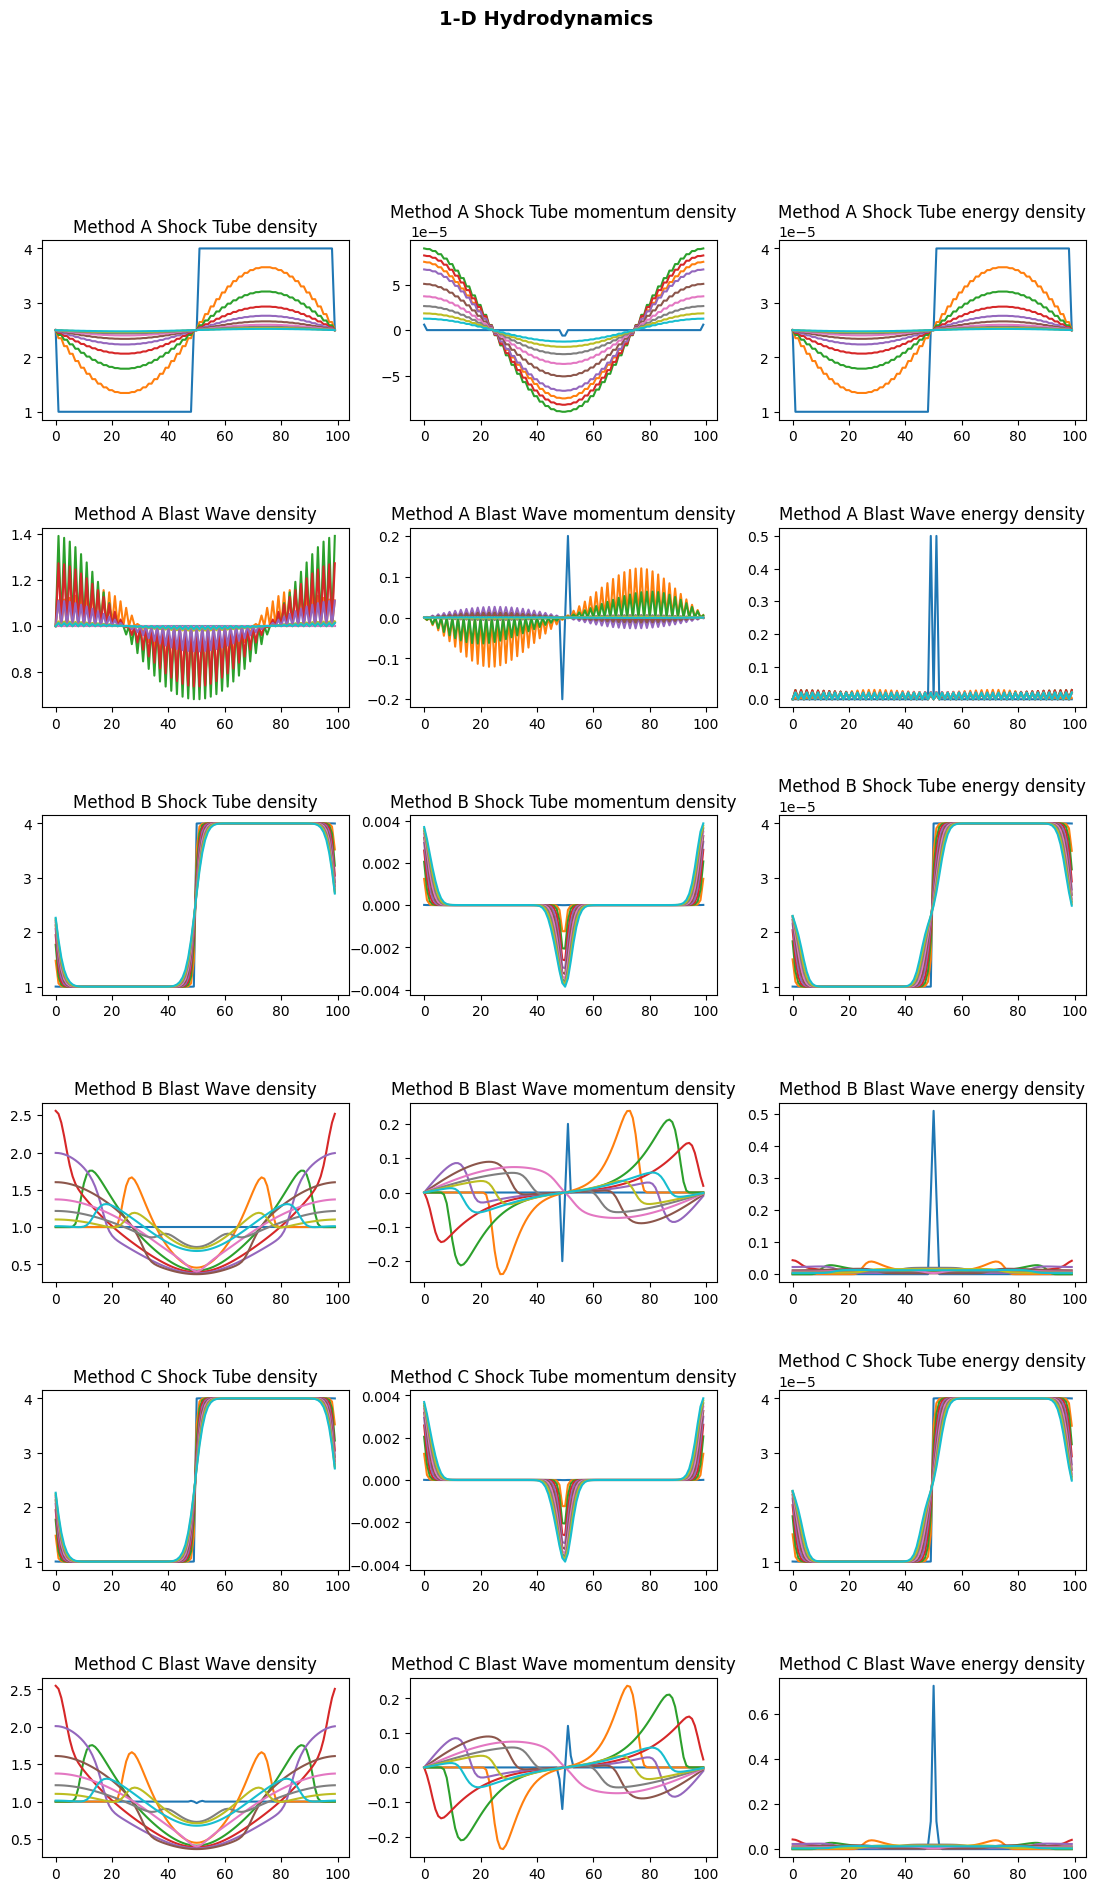

In [195]:
# size of the grid in one dimension
N = 100
# Definition of the state vector
# in every grid cell, [mass density, momentum density, energy density]
U = np.zeros((N, 3))
e = 1e-5
# gamma for a 1-dimensional problem
gamma = 3
# defines the time step, must obey the Courant Condition
deltaX = 100.0 / N
deltaT = round(0.2*deltaX,12)
tEnd = 500

def initShockTube(U):
    """sets up initial condition for the shock tube problem"""
    Unew = np.zeros_like(U)
    first = int(0.5 * N)
    # mass density rho
    Unew[:first, 0] = 1
    Unew[first:, 0] = 4
    # momentum density u
    Unew[:,1] = 0
    # defining E
    E = 0.5 * Unew[:,1] * (Unew[:,1]/Unew[:,0]) + Unew[:,0] * e
    Unew[:,2] = E

    return Unew


def initBlastWave(U):
    """sets up initial conditions for the blast wave problem"""
    Unew = np.zeros_like(U)
    # mass density rho
    Unew[:,0] = 1
    # momentum density u
    Unew[:,1] = 0
    # defining E
    E = 0.5 * Unew[:,1] * Unew[:,1]/Unew[:,0] + Unew[:,0] * e
    Unew[:,2] = E
    # adding one cell in the middle that has very large energy value of e = 1
    half = N//2
    Unew[half,2] = 0.5 * Unew[half,1] * (Unew[half,1]/Unew[half,0]) + Unew[half,0]

    return Unew


# defining the six initial conditions for the six plots
UShockA = initShockTube(U)
UShockB = initShockTube(U)
UShockC = initShockTube(U)
UBlastA = initBlastWave(U)
UBlastB = initBlastWave(U)
UBlastC = initBlastWave(U)

fig, ax = plt.subplots(6, 3, figsize=(12, 21))
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.1, top=0.87, wspace=0.2, hspace=0.6)
plt.suptitle("1-D Hydrodynamics", fontweight="bold", fontsize=14)

#method A plots
plot1 = ax[0][0]
plot2 = ax[0][1]
plot3 = ax[0][2]
plot4 = ax[1][0]
plot5 = ax[1][1]
plot6 = ax[1][2]

#method B plots
plot7 = ax[2][0]
plot8 = ax[2][1]
plot9 = ax[2][2]
plot10 = ax[3][0]
plot11 = ax[3][1]
plot12 = ax[3][2]

#method C plots
plot13 = ax[4][0]
plot14 = ax[4][1]
plot15 = ax[4][2]
plot16 = ax[5][0]
plot17 = ax[5][1]
plot18 = ax[5][2]


plot1.set_title("Method A Shock Tube density")
plot4.set_title("Method A Blast Wave density")
plot2.set_title("Method A Shock Tube momentum density")
plot5.set_title("Method A Blast Wave momentum density")
plot3.set_title("Method A Shock Tube energy density")
plot6.set_title("Method A Blast Wave energy density")

plot7.set_title("Method B Shock Tube density")
plot10.set_title("Method B Blast Wave density")
plot8.set_title("Method B Shock Tube momentum density")
plot11.set_title("Method B Blast Wave momentum density")
plot9.set_title("Method B Shock Tube energy density")
plot12.set_title("Method B Blast Wave energy density")

plot13.set_title("Method C Shock Tube density")
plot16.set_title("Method C Blast Wave density")
plot14.set_title("Method C Shock Tube momentum density")
plot17.set_title("Method C Blast Wave momentum density")
plot15.set_title("Method C Shock Tube energy density")
plot18.set_title("Method C Blast Wave energy density")

for n in range(int(tEnd/deltaT)):
    if n % (int(tEnd/deltaT/100.0)) == 0:
        print(n)
    UShockA = methodA(UShockA, deltaT, deltaX, gamma)
    if n % (int(tEnd/deltaT/1000.0)) == 0:
            print(UShockA)
    UBlastA = methodA(UBlastA, deltaT, deltaX, gamma)
    UShockB = methodB(UShockB, deltaT, deltaX, gamma)
    UBlastB = methodB(UBlastB, deltaT, deltaX, gamma)
    UShockC = methodC(UShockC, deltaT, deltaX, gamma)
    UBlastC = methodC(UBlastC, deltaT, deltaX, gamma)
    if n % (int(tEnd/deltaT/10)) == 0:
        plot1.plot(UShockA[:,0])
        plot4.plot(UBlastA[:,0])
        plot2.plot(UShockA[:,1])
        plot5.plot(UBlastA[:,1])
        plot3.plot(UShockA[:,2])
        plot6.plot(UBlastA[:,2])
        
        plot7.plot(UShockB[:,0])
        plot10.plot(UBlastB[:,0])
        plot8.plot(UShockB[:,1])
        plot11.plot(UBlastB[:,1])
        plot9.plot(UShockB[:,2])
        plot12.plot(UBlastB[:,2])
        
        plot13.plot(UShockC[:,0])
        plot16.plot(UBlastC[:,0])
        plot14.plot(UShockC[:,1])
        plot17.plot(UBlastC[:,1])
        plot15.plot(UShockC[:,2])
        plot18.plot(UBlastC[:,2])

plt.savefig("result.png",dpi=350)
plt.show()
